In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
train_df = pd.read_csv("data/raw/twitter_training.csv")
val_df   = pd.read_csv("data/raw/twitter_validation.csv")

train_df.head()


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [10]:
train_df = pd.read_csv("data/raw/twitter_training.csv", header=None)

In [12]:
train_df.columns = ['id', 'topic', 'sentiment', 'text']

In [13]:
train_df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [14]:
train_df = train_df[train_df['sentiment'].isin(['Positive', 'Negative'])]

In [15]:
train_df['label'] = train_df['sentiment'].map({'Positive': 1, 'Negative': 0})

In [16]:
X = train_df['text']
y = train_df['label']

In [19]:
train_df['text'] = train_df['text'].astype(str).fillna("")

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

In [22]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      4509
           1       0.89      0.83      0.86      4166

    accuracy                           0.87      8675
   macro avg       0.87      0.87      0.87      8675
weighted avg       0.87      0.87      0.87      8675



Matplotlib is building the font cache; this may take a moment.


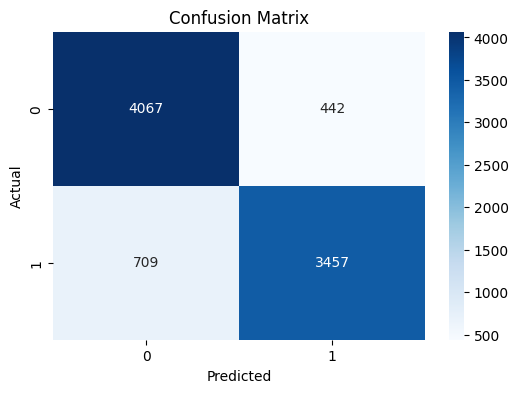

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
import joblib

joblib.dump(model, "models/sentiment_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']